In [27]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

In [28]:
nc_path = Path("../../data/out/percentiles/temp_percentiles_fullyear.nc")
ds = xr.open_dataset(nc_path)
ds

<xarray.Dataset> Size: 415MB
Dimensions:    (latitude: 1801, longitude: 3600)
Coordinates:
  * latitude   (latitude) float64 14kB 90.0 89.9 89.8 89.7 ... -89.8 -89.9 -90.0
  * longitude  (longitude) float64 29kB 0.0 0.1 0.2 0.3 ... 359.7 359.8 359.9
Data variables: (12/16)
    TX1        (latitude, longitude) float32 26MB ...
    TX2_5      (latitude, longitude) float32 26MB ...
    TX5        (latitude, longitude) float32 26MB ...
    TX10       (latitude, longitude) float32 26MB ...
    TX90       (latitude, longitude) float32 26MB ...
    TX95       (latitude, longitude) float32 26MB ...
    ...         ...
    TN5        (latitude, longitude) float32 26MB ...
    TN10       (latitude, longitude) float32 26MB ...
    TN90       (latitude, longitude) float32 26MB ...
    TN95       (latitude, longitude) float32 26MB ...
    TN97_5     (latitude, longitude) float32 26MB ...
    TN99       (latitude, longitude) float32 26MB ...

In [29]:
# Variables ordered by percentile level, TX then TN
variables = [
    "TX1",  "TX2_5",  "TX5",  "TX10",
    "TX90", "TX95",   "TX97_5", "TX99",
    "TN1",  "TN2_5",  "TN5",  "TN10",
    "TN90", "TN95",   "TN97_5", "TN99",
]

# Friendly display labels
labels = {
    "TX1":    "TX  1st pct",   "TX2_5":  "TX  2.5th pct",
    "TX5":    "TX  5th pct",   "TX10":   "TX 10th pct",
    "TX90":   "TX 90th pct",   "TX95":   "TX 95th pct",
    "TX97_5": "TX 97.5th pct", "TX99":   "TX 99th pct",
    "TN1":    "TN  1st pct",   "TN2_5":  "TN  2.5th pct",
    "TN5":    "TN  5th pct",   "TN10":   "TN 10th pct",
    "TN90":   "TN 90th pct",   "TN95":   "TN 95th pct",
    "TN97_5": "TN 97.5th pct", "TN99":   "TN 99th pct",
}

# Variables sharing the same binned color scale
categories = {
    "low_TX":  ["TX1",  "TX2_5",  "TX5",  "TX10"],
    "high_TX": ["TX90", "TX95",   "TX97_5", "TX99"],
    "low_TN":  ["TN1",  "TN2_5",  "TN5",  "TN10"],
    "high_TN": ["TN90", "TN95",   "TN97_5", "TN99"],
}

NROWS, NCOLS = 4, 4
STRIDE   = 5  # downsample factor (1801→360, 3600→720)
BIN_STEP = 4  # fixed bin width in °C; number of bins adapts to the data range
CMAP     = "RdYlBu_r"

low_TX    : p5=-33.2  p95=26.9 °C  →  16 bins of 4°C  [-36, 28]
high_TX   : p5=16.5  p95=42.3 °C  →  7 bins of 4°C  [16, 44]
low_TN    : p5=-39.5  p95=20.4 °C  →  16 bins of 4°C  [-40, 24]
high_TN   : p5=7.5  p95=28.3 °C  →  7 bins of 4°C  [4, 32]


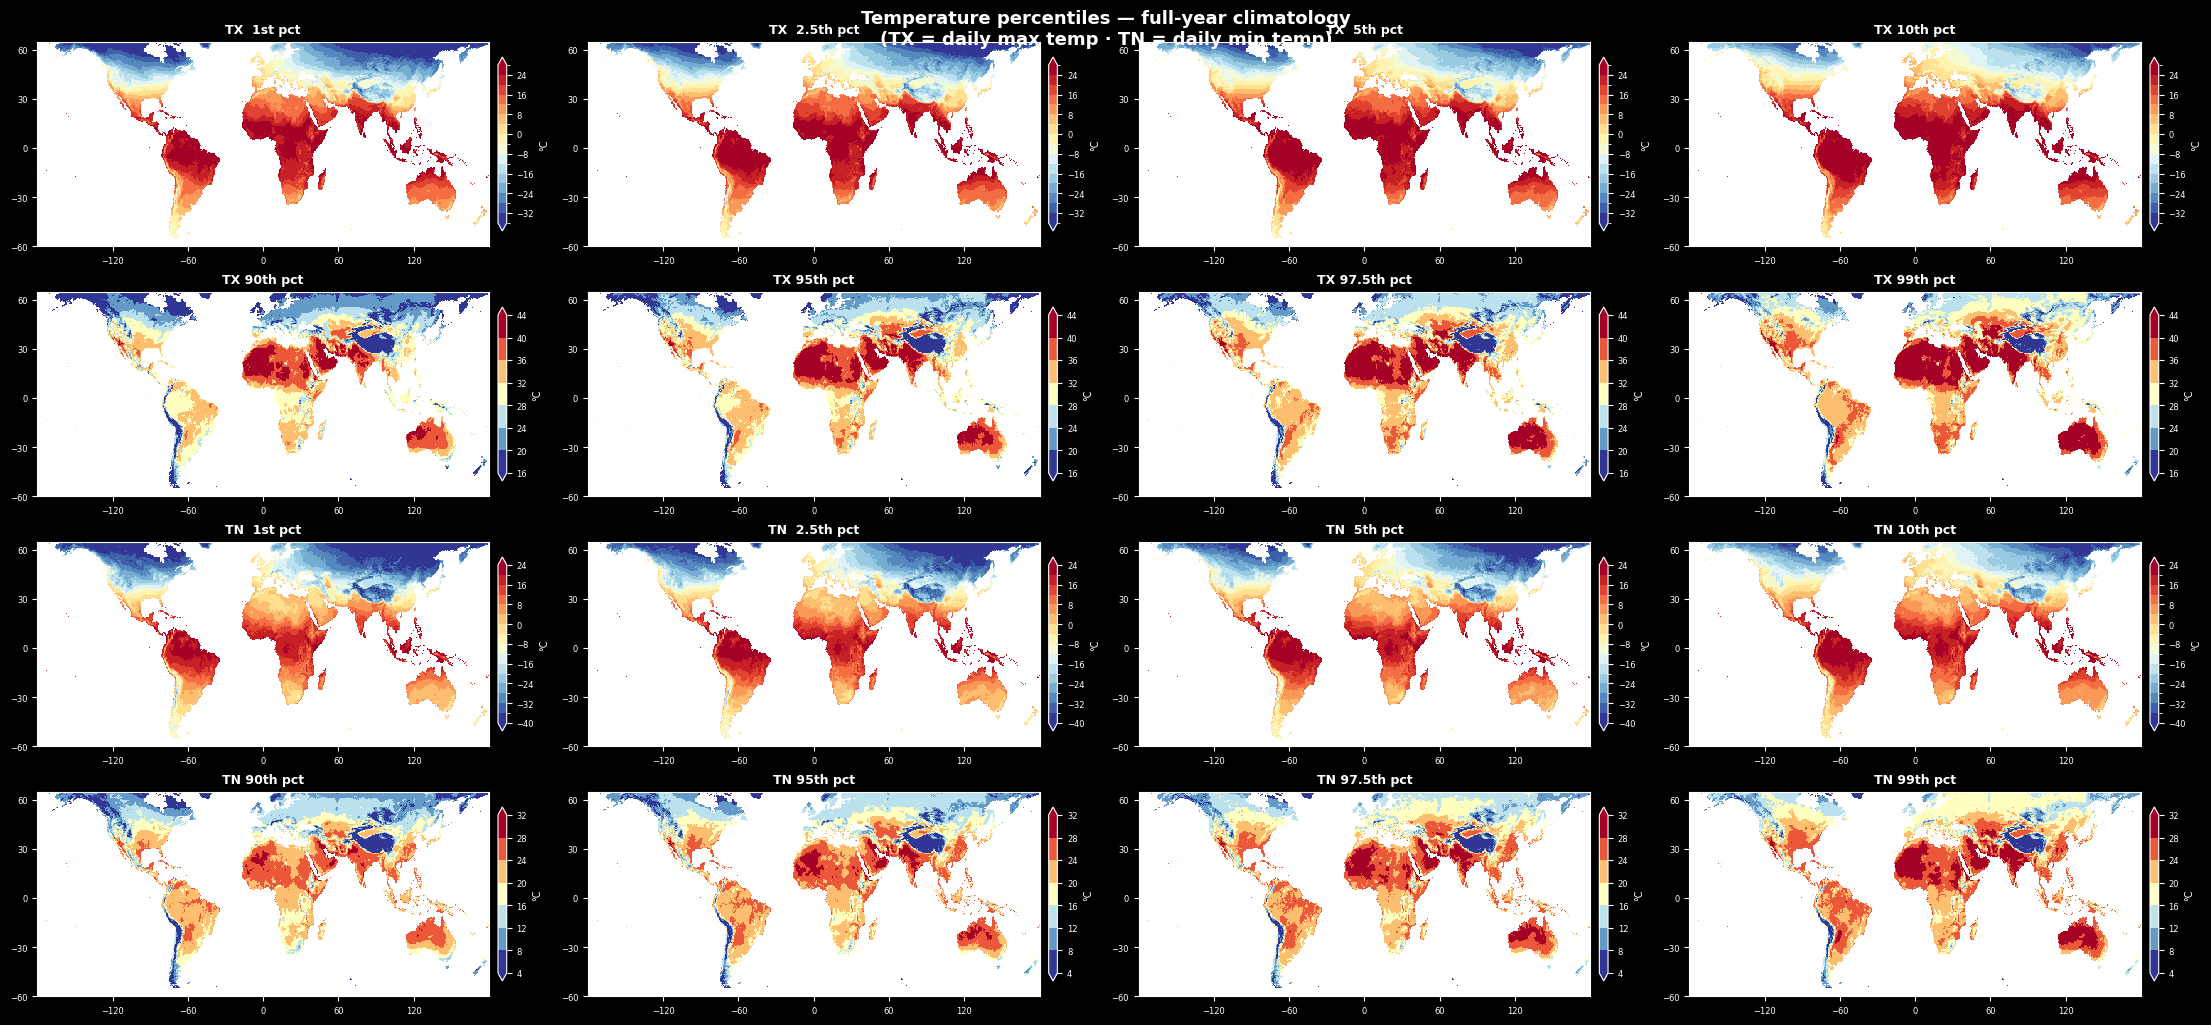

Saved → temp_percentiles_world_maps.png


In [32]:
LAT_MIN, LAT_MAX = -55, 65


def load_rolled(ds, var, stride=5):
    """Load, clip to lat bounds, downsample, roll longitude to [-180,180)."""
    data = (
        ds[var]
        .sel(latitude=slice(LAT_MAX, LAT_MIN))
        .values[::stride, ::stride]
        .astype(np.float32)
    )
    half = data.shape[1] // 2
    return np.roll(data, half, axis=1)


# Cache all data up front to avoid loading twice
data_cache = {var: load_rolled(ds, var, STRIDE) for var in variables}

# Build one BoundaryNorm per category: 4°C bins with edges at multiples of 4
var_to_cat = {var: cat for cat, grp in categories.items() for var in grp}

category_norms = {}
for cat, grp in categories.items():
    all_vals = np.concatenate([data_cache[v].ravel() for v in grp])
    p5, p95 = np.nanpercentile(all_vals, [5, 95])
    lo = np.floor(p5 / BIN_STEP) * BIN_STEP        # snap down to multiple of 4
    hi = np.ceil(p95 / BIN_STEP) * BIN_STEP         # snap up to multiple of 4
    n_bins = int(round((hi - lo) / BIN_STEP))
    bounds = np.arange(lo, hi + BIN_STEP * 0.5, BIN_STEP)
    cmap_binned = plt.get_cmap(CMAP, n_bins)
    cmap_binned.set_bad("white")                     # NaN (ocean) → white
    norm = mcolors.BoundaryNorm(bounds, ncolors=n_bins, clip=False)
    category_norms[cat] = (norm, cmap_binned)
    print(f"{cat:10s}: p5={p5:.1f}  p95={p95:.1f} °C  →  {n_bins} bins of {BIN_STEP}°C  [{lo:.0f}, {hi:.0f}]")


fig, axes = plt.subplots(
    NROWS, NCOLS,
    figsize=(22, 10),
    constrained_layout=True,
)

for ax, var in zip(axes.flat, variables):
    data = data_cache[var]
    norm, cmap_binned = category_norms[var_to_cat[var]]

    im = ax.imshow(
        data,
        origin="upper",
        extent=[-180, 180, LAT_MIN, LAT_MAX],
        aspect="auto",
        cmap=cmap_binned,
        norm=norm,
        interpolation="nearest",
    )

    ax.set_title(labels[var], fontsize=9, fontweight="bold")
    ax.set_xticks([-120, -60, 0, 60, 120])
    ax.set_yticks([-60, -30, 0, 30, 60])
    ax.tick_params(labelsize=6)
    ax.set_facecolor("white")

    cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02, extend="both")
    cbar.ax.tick_params(labelsize=6)
    cbar.set_label("°C", fontsize=7)

fig.suptitle(
    "Temperature percentiles — full-year climatology\n"
    "(TX = daily max temp · TN = daily min temp)",
    fontsize=13, fontweight="bold", y=1.01,
)

plt.savefig("./temp_percentiles_world_maps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → temp_percentiles_world_maps.png")